# Feature Engineering - EDA

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# consts
cleaned_file_path = "../temp/cleaned_dataSet.csv"

In [20]:
# Load the dataset
df = pd.read_csv(cleaned_file_path)

In [21]:
# 1. Derive Comorbidity score from the data set

df['Comorbidity_Score'] = (
    df["diabetes_flag"] +
    df["hypertension_flag"] +
    df["heart_disease_flag"] 
)

print(df.shape)
print(df.columns)

(50000, 28)
Index(['patient_id', 'age', 'gender', 'bmi', 'smoking_status', 'diabetes_flag',
       'hypertension_flag', 'heart_disease_flag', 'chronic_conditions_count',
       'previous_admissions_12m', 'length_of_stay_days', 'icu_admission_flag',
       'emergency_admission_flag', 'number_of_procedures', 'blood_glucose',
       'cholesterol_level', 'hemoglobin', 'creatinine', 'medications_count',
       'high_risk_medication_flag', 'medication_changes_during_stay',
       'followup_scheduled_flag', 'discharge_destination',
       'patient_education_score', 'insurance_type', 'treatment_cost',
       'readmission_flag', 'Comorbidity_Score'],
      dtype='object')


Readmission Count:
 readmission_flag
0    32659
1    17341
Name: count, dtype: int64


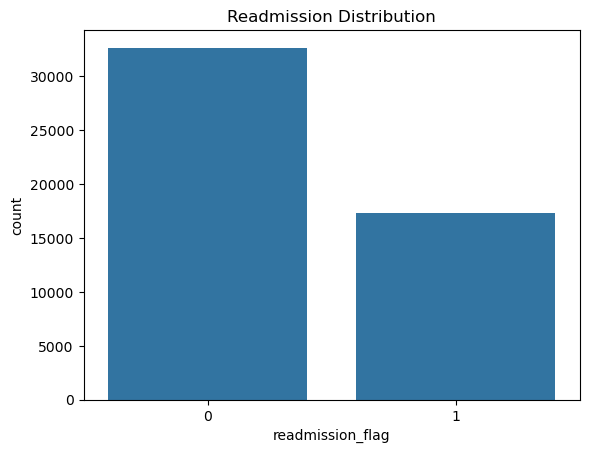

In [22]:
readmission_count = df['readmission_flag'].value_counts()
print("Readmission Count:\n", readmission_count)

plt.figure()
sns.countplot(x='readmission_flag', data=df)
plt.title('Readmission Distribution')
plt.show()

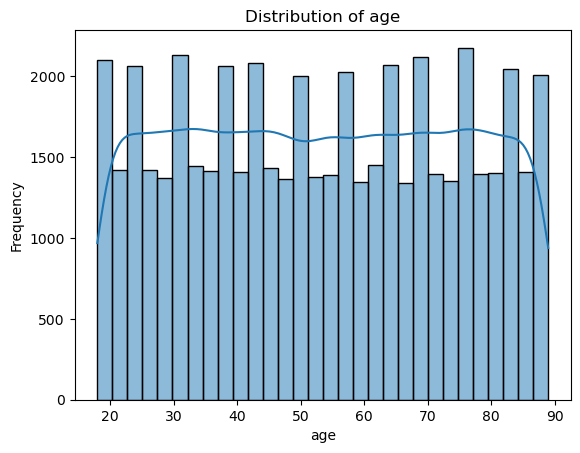

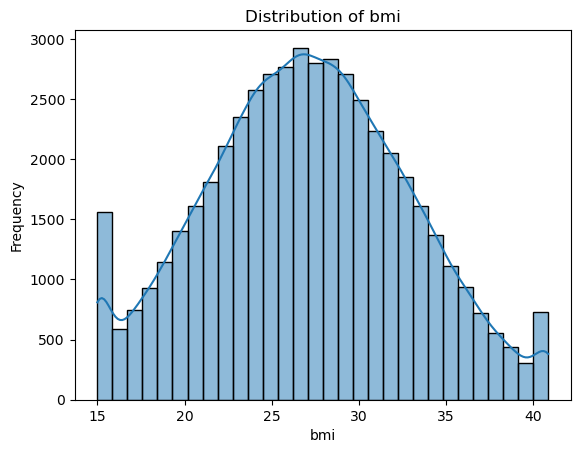

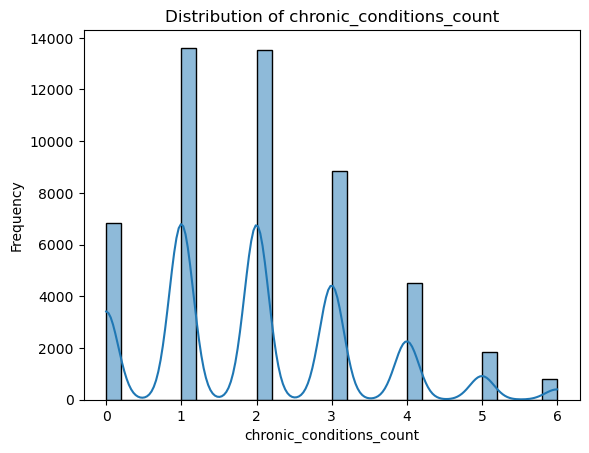

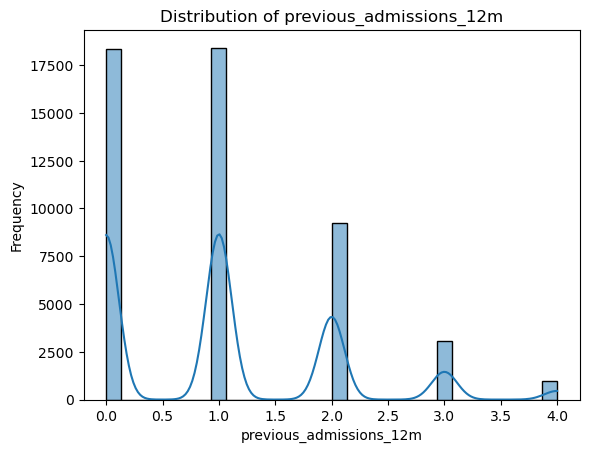

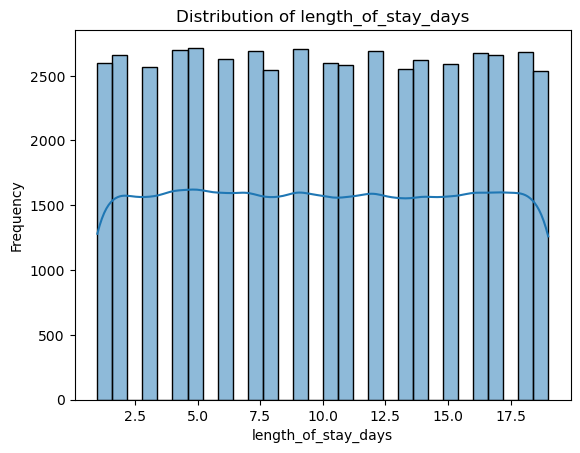

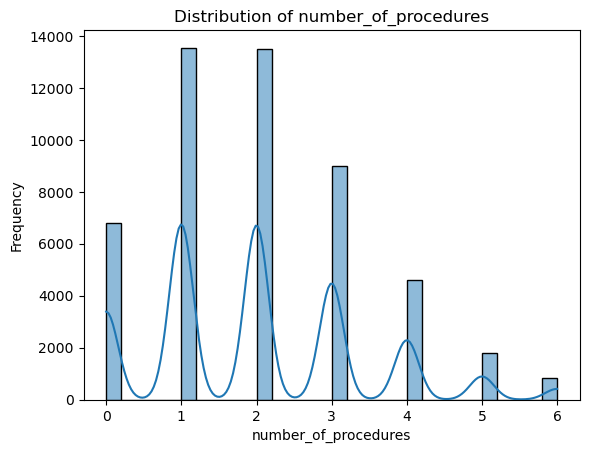

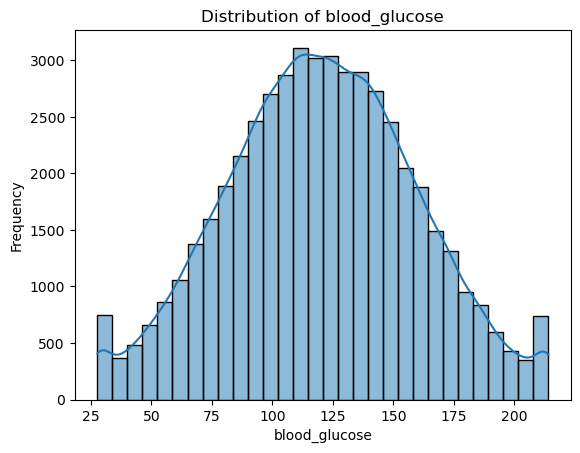

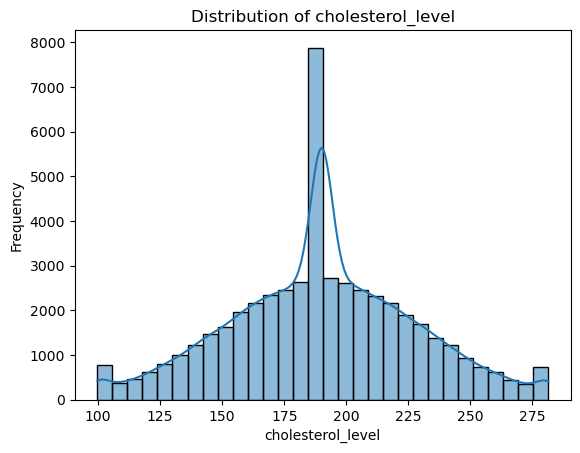

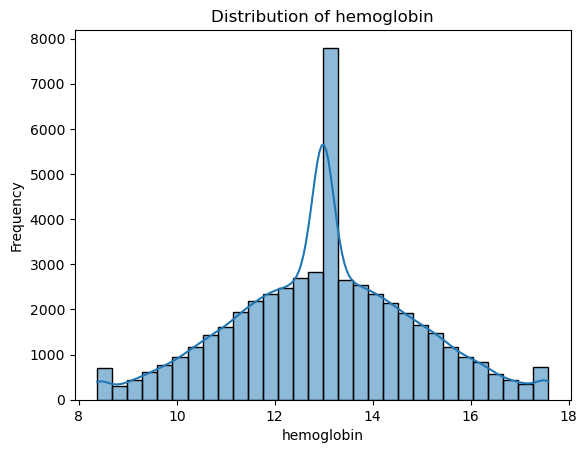

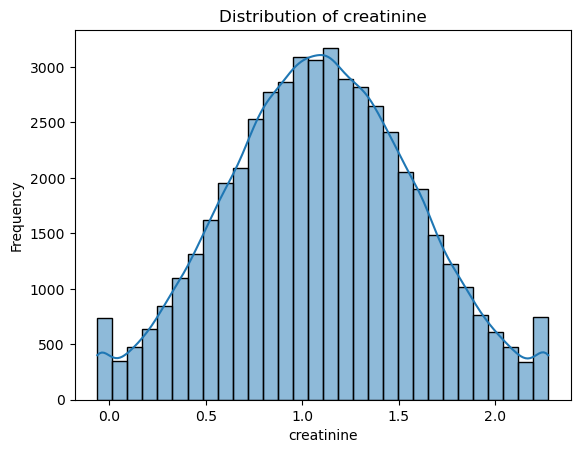

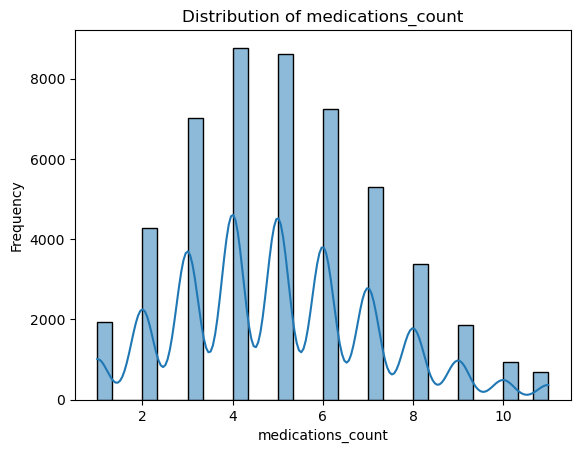

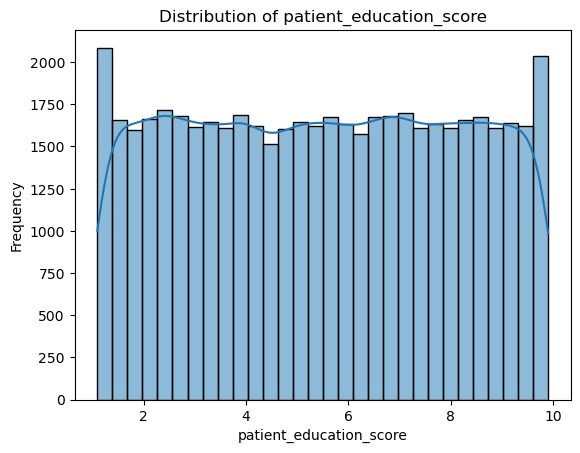

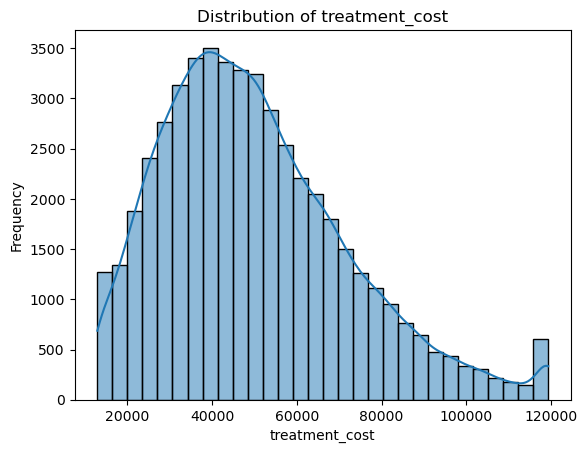

In [23]:
numeric_cols = [
    "age", 
    "bmi", 
    "chronic_conditions_count", 
    "previous_admissions_12m", 
    "length_of_stay_days", 
    "number_of_procedures", 
    "blood_glucose", 
    "cholesterol_level", 
    "hemoglobin", 
    "creatinine", 
    "medications_count",
    "patient_education_score",
    "treatment_cost"
]

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

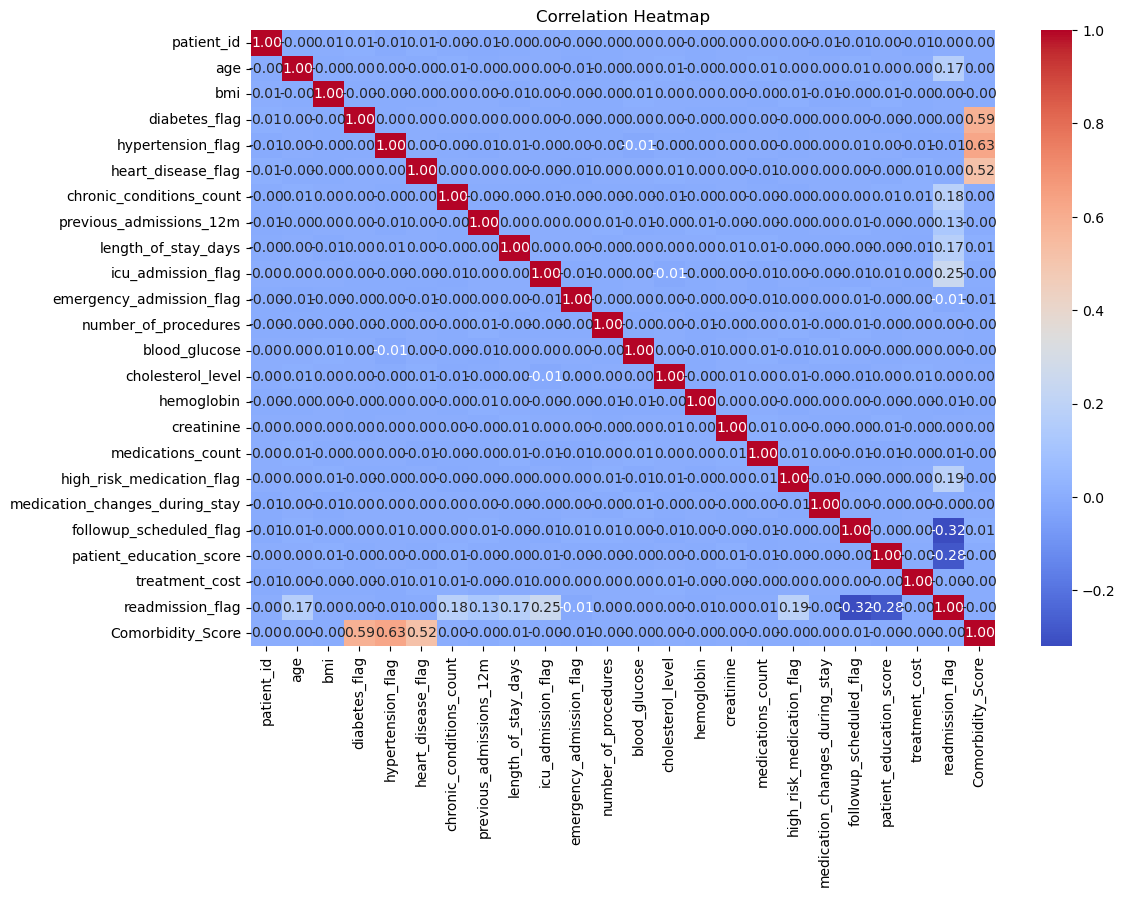

In [24]:
#plot heatmap for correlation
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()